# **Phase 3 - Multimodal Emotion Recognition (MER)**
**FER + SER => Fusion Model : MER**

In [ ]:
# ============================================================
# CELL 1 — Mount Drive + Setup Paths
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os, random, json, pickle
import numpy as np
import torch

# ============================================================
# REPRODUCIBILITY
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# PATHS  (same structure as Notebooks 1 & 2)
# ============================================================
BASE_PATH         = "/content/drive/MyDrive/Emotion_Story_Project1"
DATA_PATH         = os.path.join(BASE_PATH, "data")
MODEL_PATH        = os.path.join(BASE_PATH, "models")
FACIAL_MODEL_PATH = os.path.join(MODEL_PATH, "facial")
AUDIO_MODEL_PATH  = os.path.join(MODEL_PATH, "audio")
FUSION_MODEL_PATH = os.path.join(MODEL_PATH, "fusion")
OUTPUT_PATH       = os.path.join(BASE_PATH, "outputs")
METRIC_PATH       = os.path.join(OUTPUT_PATH, "metrics")
LOG_PATH          = os.path.join(BASE_PATH, "logs")

for p in [FUSION_MODEL_PATH, METRIC_PATH, LOG_PATH]:
    os.makedirs(p, exist_ok=True)

assert os.path.exists(BASE_PATH), f"❌ Base path not found: {BASE_PATH}"

print("=" * 60)
print("✅ Drive mounted. Paths verified.")
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
print("=" * 60)

Mounted at /content/drive
✅ Drive mounted. Paths verified.
PyTorch  : 2.11.0+cu128
CUDA     : True
GPU      : Tesla T4


In [ ]:
# ============================================================
# CELL 2 — Imports
# ============================================================

import gc, cv2, time, librosa, warnings, traceback
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

from PIL import Image
from collections import deque
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    f1_score, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print(f"✅ Device: {device}")

✅ Device: cuda


In [ ]:
# ============================================================
# CELL 3 — Global Config
# ============================================================

# ── Audio ────────────────────────────────────────────────────
SR           = 22050
N_MELS       = 128
FIXED_LENGTH = 3
SAMPLES      = SR * FIXED_LENGTH
EPSILON      = 1e-8

# ── Emotion Space ────────────────────────────────────────────
COMMON_EMOTIONS = ["Happy", "Neutral", "Sad"]
NUM_CLASSES     = len(COMMON_EMOTIONS)

AUDIO_TO_COMMON  = {"happy": "Happy", "calm": "Neutral",
                    "neutral": "Neutral", "sad": "Sad"}
FACIAL_TO_COMMON = {"happy": "Happy", "neutral": "Neutral", "sad": "Sad"}

FACE_CLASSES  = COMMON_EMOTIONS
AUDIO_CLASSES = COMMON_EMOTIONS

print("✅ FACE_CLASSES and AUDIO_CLASSES defined")

# ── Temporal Stabilisation ───────────────────────────────────
BUFFER_SIZE        = 15       # rolling window
EMA_ALPHA          = 0.35     # EMA weight for current frame
TRANSITION_PENALTY = 0.12     # inertia penalty

# ── Fusion ───────────────────────────────────────────────────
MIN_RELIABILITY    = 0.15
CONFLICT_THRESHOLD = 0.60

# ── Context Awareness ────────────────────────────────────────
# If the child has been detected sad for N consecutive frames,
# the system biases toward 'Sad' to avoid false recovery signal.
CONTEXT_WINDOW     = 5        # frames to build context
CONTEXT_WEIGHT     = 0.15     # how much context biases fusion

# ── Temperature Scaling (calibration) ───────────────────────
FACE_TEMPERATURE   = 1.2      # >1 = soften face probs
AUDIO_TEMPERATURE  = 1.0      # tuned after eval on test set

# ── Uncertainty ──────────────────────────────────────────────
# Entropy above this → flag as "uncertain" in Phase 4 UI
UNCERTAINTY_THRESHOLD = 1.10  # bits (max for 3 classes ≈ 1.585)

# ── Debug ────────────────────────────────────────────────────
DEBUG_MODE = True

print("✅ Configuration loaded")

✅ FACE_CLASSES and AUDIO_CLASSES defined
✅ Configuration loaded


In [ ]:
# ============================================================
# CELL 4 — AudioCNN Architecture (exact copy from NB2)
# ============================================================

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(channels)
        self.se    = SEBlock(channels)
    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        return F.relu(out + identity)


class AudioCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.conv1  = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1    = nn.BatchNorm2d(32)
        self.res1   = ResidualBlock(32)
        self.pool1  = nn.MaxPool2d(2)
        self.drop1  = nn.Dropout(0.2)
        self.conv2  = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2    = nn.BatchNorm2d(64)
        self.res2   = ResidualBlock(64)
        self.pool2  = nn.MaxPool2d(2)
        self.drop2  = nn.Dropout(0.3)
        self.conv3  = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3    = nn.BatchNorm2d(128)
        self.pool3  = nn.MaxPool2d(2)
        self.drop3  = nn.Dropout(0.3)
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.fc1    = nn.Linear(128, 64)
        self.drop_fc = nn.Dropout(0.4)
        self.fc2    = nn.Linear(64, num_classes)
    def forward(self, x):
        x = self.drop1(self.pool1(self.res1(F.relu(self.bn1(self.conv1(x))))))
        x = self.drop2(self.pool2(self.res2(F.relu(self.bn2(self.conv2(x))))))
        x = self.drop3(self.pool3(F.relu(self.bn3(self.conv3(x)))))
        x = self.gap(x).view(x.size(0), -1)
        x = self.drop_fc(F.relu(self.fc1(x)))
        return self.fc2(x)

# quick sanity check
_ = AudioCNN()(torch.randn(1, 3, 128, 173))
print("✅ AudioCNN architecture verified")

✅ AudioCNN architecture verified


In [ ]:
# ============================================================
# CELL 5 — Load Pre-trained FER + SER Models
# ============================================================
# SER loading strategy:
#   PRIMARY  → ensemble_audio_model.pth  (list of 3 state_dicts, stronger)
#   FALLBACK → final_best_audio_model.pth (single best seed, simpler)
# predict_audio_emotion() (Cell 9) averages softmax across all
# loaded SER models automatically — no changes needed there.
# ============================================================

def _load_checkpoint(model, path):
    ckpt = torch.load(path, map_location=device, weights_only=True)
    if isinstance(ckpt, list):
        ckpt = ckpt[0]
    if isinstance(ckpt, dict) and list(ckpt.keys())[0].startswith("module."):
        ckpt = {k.replace("module.", ""): v for k, v in ckpt.items()}
    model.load_state_dict(ckpt)
    return model

# ── Facial model ──────────────────────────────────────────────

face_model_path = os.path.join(FACIAL_MODEL_PATH, "best_face_model_stage2_3class.pth")
assert os.path.exists(face_model_path), f"❌ FER model not found: {face_model_path}"

face_model = models.efficientnet_b2(weights=None)
in_features = face_model.classifier[1].in_features

face_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, NUM_CLASSES)
)
face_model = _load_checkpoint(face_model, face_model_path).to(device).eval()

print("✅ FER model loaded")

# ── Audio model — ensemble preferred, single-seed fallback ───

ensemble_bundle_path = os.path.join(AUDIO_MODEL_PATH, "ensemble_audio_model.pth")
single_model_path    = os.path.join(AUDIO_MODEL_PATH, "final_best_audio_model.pth")

if os.path.exists(ensemble_bundle_path):
    # ── Load all 3 seed state_dicts and build ensemble list ──
    state_dicts  = torch.load(ensemble_bundle_path, map_location=device, weights_only=True)
    audio_models = []
    for i, sd in enumerate(state_dicts):
        m = AudioCNN(num_classes=NUM_CLASSES)
        m.load_state_dict(sd)
        m.to(device).eval()
        audio_models.append(m)
    USE_ENSEMBLE = True
    print(f"✅ SER ensemble loaded  ({len(audio_models)} models "
          f"from ensemble_audio_model.pth)")

else:
    # ── Fallback: single best-seed model ─────────────────────
    assert os.path.exists(single_model_path), (
        f"❌ Neither ensemble nor single SER model found.\n"
        f"   Ensemble path : {ensemble_bundle_path}\n"
        f"   Single path   : {single_model_path}"
    )
    audio_model  = AudioCNN(num_classes=NUM_CLASSES)
    audio_model  = _load_checkpoint(audio_model, single_model_path).to(device).eval()
    audio_models = [audio_model]   # wrap in list — Cell 9 iterates over this
    USE_ENSEMBLE = False
    print(f"⚠️  Ensemble bundle not found — loaded single SER model "
          f"(final_best_audio_model.pth)")

print(f"   USE_ENSEMBLE : {USE_ENSEMBLE}")

# ── Summary ───────────────────────────────────────────────────

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"\nFER params : {sum(p.numel() for p in face_model.parameters()):,}")
print(f"SER params : {sum(p.numel() for p in audio_models[0].parameters()):,}")
print(f"SER models : {len(audio_models)}  "
      f"({'ensemble' if USE_ENSEMBLE else 'single'})")

✅ FER model loaded
✅ SER ensemble loaded  (3 models from ensemble_audio_model.pth)
   USE_ENSEMBLE : True

FER params : 7,705,221
SER params : 196,271
SER models : 3  (ensemble)


In [ ]:
# ============================================================
# CELL 6 — Face Preprocessing Pipeline
# ============================================================

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
assert not face_detector.empty(), "❌ Haar Cascade failed to load"

face_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229, 0.224, 0.225])
])

def compute_face_quality(gray_face):
    blur        = cv2.Laplacian(gray_face, cv2.CV_64F).var()
    brightness  = np.mean(gray_face)
    blur_norm   = min(blur / 1000.0, 1.0)
    bright_norm = 1.0 - abs(brightness - 127) / 127.0
    return float(np.clip(0.7 * blur_norm + 0.3 * bright_norm, 0, 1))


def preprocess_face(image_source):
    """
    Accepts:
      - str  : file path
      - np.ndarray : BGR frame from webcam
    Returns (tensor | None, quality_score, pil_face | None)
    """
    if isinstance(image_source, str):
        image = cv2.imread(image_source)
        if image is None:
            raise ValueError(f"Cannot load image: {image_source}")
    else:
        image = image_source.copy()

    gray  = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_detector.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60)
    )

    if len(faces) == 0:
        return None, 0.0, None

    x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
    face_crop   = image[y:y+h, x:x+w]
    gray_crop   = gray[y:y+h, x:x+w]
    quality     = compute_face_quality(gray_crop)

    face_rgb  = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
    pil_face  = Image.fromarray(face_rgb)
    tensor    = face_transform(pil_face)

    if torch.isnan(tensor).any():
        raise ValueError("NaN in face tensor")

    return tensor.unsqueeze(0).to(device), quality, pil_face

print("✅ Face preprocessing ready")

✅ Face preprocessing ready


In [ ]:
# ============================================================
# CELL 7 - Audio Feature Extraction
# ============================================================

def generate_features(audio_source):
    try:
        if isinstance(audio_source, str):
            y, sr = librosa.load(audio_source, sr=SR)
        else:
            y, sr = audio_source, SR

        # ── Must match NB2 exactly ──────────────────────────
        # Step 1: trim silence
        y, _ = librosa.effects.trim(y, top_db=20)

        # Step 2: amplitude normalize
        y = librosa.util.normalize(y)

        # Step 3: pad or trim
        if len(y) < SAMPLES:
            y = np.pad(y, (0, SAMPLES - len(y)))
        else:
            y = y[:SAMPLES]

        # Step 4: mel spectrogram — exact NB2 params
        mel    = librosa.feature.melspectrogram(
            y=y, sr=sr,
            n_fft=2048, hop_length=512,
            win_length=2048, n_mels=N_MELS
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)
        delta  = librosa.feature.delta(mel_db)
        delta2 = librosa.feature.delta(mel_db, order=2)

        stacked = np.stack([mel_db, delta, delta2], axis=0)

        # Step 5: channel-wise normalization (NOT global)
        for i in range(3):
            stacked[i] = (stacked[i] - stacked[i].mean()) / \
                         (stacked[i].std() + 1e-6)

        if np.isnan(stacked).any() or np.isinf(stacked).any():
            raise ValueError("NaN/Inf in features")

        return stacked.astype(np.float32)

    except Exception as e:
        print(f"❌ Audio feature error: {e}")
        return None

In [ ]:
# ============================================================
# CELL 8 — Temperature Scaling Calibration
# ============================================================
# Temperature scaling softens / sharpens softmax output.
# T > 1  → softer probabilities (less over-confident)
# T = 1  → unchanged
# T < 1  → sharper probabilities
# We apply it per-modality before fusion.

def temperature_scale(logits_or_probs, temperature, from_probs=True):
    """
    Apply temperature scaling to a numpy probability vector.
    Since we already have softmax probs from the model,
    we convert back to log-domain, scale, then re-softmax.
    """
    log_p  = np.log(np.clip(logits_or_probs, 1e-9, 1.0))
    scaled = log_p / temperature
    # numerically stable softmax
    shifted = scaled - np.max(scaled)
    exp_p   = np.exp(shifted)
    return exp_p / exp_p.sum()


def prediction_entropy(probs):
    """Shannon entropy in bits. Max = log2(num_classes)."""
    probs = np.clip(probs, 1e-9, 1.0)
    return float(-np.sum(probs * np.log2(probs)))

print("✅ Temperature scaling + uncertainty helpers ready")

✅ Temperature scaling + uncertainty helpers ready


In [ ]:
# ============================================================
# CELL 9 — Unimodal Prediction Functions (TTA for face)
# ============================================================

# ── TTA transforms for face ──────────────────────────────────

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

_TTA_TRANSFORMS = [
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(3),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.Grayscale(3),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]),
    transforms.Compose([
        transforms.Resize((232, 232)),
        transforms.CenterCrop(224),
        transforms.Grayscale(3),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]),
    transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(3),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # PIL-level jitter on gray
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
]),
]


def predict_face_emotion_tta(image_source):
    """
    Face prediction with 4-augment TTA.
    Accepts file path or BGR numpy frame.
    """
    try:
        # Reuse preprocess_face for detection and quality estimation
        _, quality, pil_face = preprocess_face(image_source)
        if pil_face is None:
            return {"emotion": "Neutral", "probabilities": np.array([0.33,0.34,0.33]),
                    "confidence": 0.0, "quality": 0.0, "reliability": 0.0,
                    "entropy": 1.585, "valid": False}

        # ── TTA inference ────────────────────────────────────
        tta_probs = []
        with torch.inference_mode():
            for tfm in _TTA_TRANSFORMS:
                t = tfm(pil_face).unsqueeze(0).to(device)
                out  = face_model(t)
                prob = torch.softmax(out, dim=1).cpu().numpy()[0]
                tta_probs.append(prob)

        face_probs = np.mean(tta_probs, axis=0)

        # ── Temperature calibration ──────────────────────────
        face_probs = temperature_scale(face_probs, FACE_TEMPERATURE)

        pred_idx     = int(np.argmax(face_probs))
        confidence   = float(np.max(face_probs))
        reliability  = 0.7 * confidence + 0.3 * quality
        entropy      = prediction_entropy(face_probs)

        return {
            "emotion":       FACE_CLASSES[pred_idx],
            "probabilities": face_probs,
            "confidence":    confidence,
            "quality":       quality,
            "reliability":   reliability,
            "entropy":       entropy,
            "valid":         True
        }

    except Exception as e:
        print(f"❌ Face TTA failed: {e}")
        return {"emotion": "Neutral", "probabilities": np.array([0.33,0.34,0.33]),
                "confidence": 0.0, "quality": 0.0, "reliability": 0.0,
                "entropy": 1.585, "valid": False}


def predict_audio_emotion(audio_source):
    """
    SER prediction.
    Accepts file path or raw np.ndarray (at SR sample rate).
    """
    try:
        # compute quality BEFORE feature extraction
        if isinstance(audio_source, str):
            y_raw, _ = librosa.load(audio_source, sr=SR)
        else:
            y_raw = audio_source
        rms = float(np.sqrt(np.mean(y_raw ** 2)))
        quality = min(rms / 0.1, 1.0) # 0.1 RMS = full quality

        feats = generate_features(audio_source)
        if feats is None:
            raise ValueError("Feature extraction returned None")

        tensor = torch.tensor(feats).unsqueeze(0).to(device)

        with torch.inference_mode():
          ensemble_probs = None
          for m in audio_models:
            p = torch.softmax(m(tensor), dim=1)
            ensemble_probs = p if ensemble_probs is None else ensemble_probs + p
          probs = (ensemble_probs / len(audio_models)).cpu().numpy()[0]

        # ── Temperature calibration ──────────────────────────
        audio_probs = temperature_scale(probs, AUDIO_TEMPERATURE)

        pred_idx    = int(np.argmax(audio_probs))
        confidence  = float(np.max(audio_probs))
        reliability = 0.6 * confidence + 0.4 * quality
        entropy     = prediction_entropy(audio_probs)

        return {
            "emotion":       AUDIO_CLASSES[pred_idx],
            "probabilities": audio_probs,
            "confidence":    confidence,
            "quality":       quality,
            "reliability":   reliability,
            "entropy":       entropy,
            "valid":         True
        }

    except Exception as e:
        print(f"❌ Audio prediction failed: {e}")
        return {"emotion": "Neutral", "probabilities": np.array([0.33,0.34,0.33]),
                "confidence": 0.0, "quality": 0.0, "reliability": 0.0,
                "entropy": 1.585, "valid": False}

print("✅ Unimodal prediction functions (with TTA + calibration) ready")

✅ Unimodal prediction functions (with TTA + calibration) ready


In [ ]:
# ============================================================
# CELL 10 — Context Awareness Module
# ============================================================
# Tracks recent emotion history and builds a context prior.
# This prior slightly biases fusion toward the observed trend,
# preventing rapid oscillation and catching sustained states
# (e.g. a child who has been sad for several frames).

class ContextAwareness:
    """
    Maintains a sliding window of recent emotions.
    Returns a context prior (probability vector) derived
    from that history.
    """

    def __init__(self, window=CONTEXT_WINDOW, num_classes=NUM_CLASSES):
        self.window      = window
        self.num_classes = num_classes
        self.history     = deque(maxlen=window)

    def update(self, emotion: str):
        idx = COMMON_EMOTIONS.index(emotion)
        self.history.append(idx)

    def get_prior(self):
        """
        Returns a np array [p_Happy, p_Neutral, p_Sad] based
        on recent history. Returns uniform if history empty.
        """
        if len(self.history) == 0:
            return np.ones(self.num_classes) / self.num_classes

        counts = np.zeros(self.num_classes)
        # more recent frames get higher weight
        for rank, idx in enumerate(self.history):
            weight = (rank + 1) / len(self.history)   # linear ramp
            counts[idx] += weight

        prior = counts / counts.sum()
        return prior

    def dominant_emotion(self):
        """Most common emotion in window (for logging)."""
        if len(self.history) == 0:
            return "Unknown"
        counts = np.bincount(list(self.history), minlength=self.num_classes)
        return COMMON_EMOTIONS[int(np.argmax(counts))]

    def reset(self):
        self.history.clear()


# Global session context (reset when a new session starts)
session_context = ContextAwareness()

print("✅ Context Awareness module ready")

✅ Context Awareness module ready


In [ ]:
# ============================================================
# CELL 11 — Learned MLP Fusion Model
# ============================================================
# Instead of hand-crafted weights, we train a small MLP
# that learns to fuse modality probabilities + reliability
# + context prior into a final prediction.
#
# Input  (dim = 3+3+3+2 = 11):
#   - face_probs      [3]
#   - audio_probs     [3]
#   - context_prior   [3]
#   - reliabilities   [2]  (face_rel, audio_rel)
#
# Output (dim = 3): fused emotion logits
# ============================================================

FUSION_INPUT_DIM = NUM_CLASSES * 3 + 2   # 11

class FusionMLP(nn.Module):

    def __init__(self, input_dim=FUSION_INPUT_DIM, hidden=64, num_classes=NUM_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


fusion_model = FusionMLP().to(device)

# quick shape check
test_in = torch.randn(4, FUSION_INPUT_DIM).to(device)
assert fusion_model(test_in).shape == (4, NUM_CLASSES)
print(f"✅ FusionMLP ready  |  params: {sum(p.numel() for p in fusion_model.parameters()):,}")

✅ FusionMLP ready  |  params: 3,075


In [ ]:
# ============================================================
# CELL 12 — Build Fusion Training Dataset  (with Drive cache)
# ============================================================
# Reads from:
# fusion_test_data/train/happy/faces/   (100 images)
# fusion_test_data/train/happy/audio/   (100 wav files)
# fusion_test_data/train/neutral/...
# fusion_test_data/train/sad/...
# Pairs them 1:1 by sorted filename order.
# Context is FLAT during harvest — no history bias.
#
# Cache behaviour:
#   • First run  → harvests features, saves .npz to Drive (~few mins)
#   • On restart → loads .npz from Drive directly        (~2 seconds)
#   • Set FORCE_REBUILD = True if you retrained NB1/NB2
#     or changed the fusion_test_data/ files.
# ============================================================

import glob, copy
import numpy as np

# ── Cache config ──────────────────────────────────────────────
CACHE_PATH    = os.path.join(FUSION_MODEL_PATH, "fusion_dataset_cache.npz")
FORCE_REBUILD = False   # ← set True only if NB1/NB2 retrained or dataset changed

# ── Paths ─────────────────────────────────────────────────────
FUSION_DATA_PATH  = os.path.join(DATA_PATH, "fusion_test_data")
FUSION_TRAIN_PATH = os.path.join(FUSION_DATA_PATH, "train")
FUSION_TEST_PATH  = os.path.join(FUSION_DATA_PATH, "test")

assert os.path.exists(FUSION_TRAIN_PATH), f"❌ Not found: {FUSION_TRAIN_PATH}"
assert os.path.exists(FUSION_TEST_PATH),  f"❌ Not found: {FUSION_TEST_PATH}"

# ── Helper: load sorted paired files from one emotion folder ──
def load_paired_samples(split_path, emotion):
    """
    Returns list of (face_path, audio_path, label) tuples
    paired 1:1 by sorted filename order.
    """
    face_dir  = os.path.join(split_path, emotion, "faces")
    audio_dir = os.path.join(split_path, emotion, "audio")

    face_files  = sorted(
        glob.glob(os.path.join(face_dir,  "*.png")) +
        glob.glob(os.path.join(face_dir,  "*.jpg"))
    )
    audio_files = sorted(
        glob.glob(os.path.join(audio_dir, "*.wav"))
    )

    if len(face_files) == 0:
        raise FileNotFoundError(f"❌ No face images found in: {face_dir}")
    if len(audio_files) == 0:
        raise FileNotFoundError(f"❌ No audio files found in: {audio_dir}")
    if len(face_files) != len(audio_files):
        print(f"⚠️  {emotion}: {len(face_files)} faces vs "
              f"{len(audio_files)} audio — using min({len(face_files)},{len(audio_files)})")

    n = min(len(face_files), len(audio_files))
    label = emotion.capitalize()
    return [(face_files[i], audio_files[i], label) for i in range(n)]


# ── Always build sample lists (lightweight — no inference) ────
train_samples, test_samples = [], []

for emo in ["happy", "neutral", "sad"]:
    pairs = load_paired_samples(FUSION_TRAIN_PATH, emo)
    train_samples.extend(pairs)
    print(f"✅ Train {emo:7s}: {len(pairs)} pairs")

print(f"\nTotal train samples : {len(train_samples)}")

for emo in ["happy", "neutral", "sad"]:
    pairs = load_paired_samples(FUSION_TEST_PATH, emo)
    test_samples.extend(pairs)
    print(f"✅ Test  {emo:7s}: {len(pairs)} pairs")

print(f"Total test samples  : {len(test_samples)}")


# ── Cache load or fresh harvest ───────────────────────────────
if FORCE_REBUILD and os.path.exists(CACHE_PATH):
    os.remove(CACHE_PATH)
    print("\n🗑️  FORCE_REBUILD=True — cache cleared, rebuilding fresh.")

if os.path.exists(CACHE_PATH):
    # ── FAST PATH: load precomputed features from Drive ───────
    print(f"\n⚡ Cache found — loading precomputed features from Drive...")
    cache    = np.load(CACHE_PATH)
    X_fusion = cache["X_fusion"]
    y_fusion = cache["y_fusion"]
    X_test   = cache["X_test"]
    y_test   = cache["y_test"]

    print(f"   X_fusion : {X_fusion.shape}  |  y_fusion: {y_fusion.shape}")
    print(f"   X_test   : {X_test.shape}    |  y_test  : {y_test.shape}")
    print(f"   ✅ Skipped harvest — ready in seconds.")

else:
    # ── SLOW PATH: run inference on all pairs, then cache ─────
    print("\n🔍 No cache found — harvesting unimodal features from train set...")
    print(f"    (one-time cost: ~few minutes for {len(train_samples)} samples)")

    X_fusion, y_fusion = [], []
    skipped = 0

    for i, (f_path, a_path, label) in enumerate(train_samples):
        try:
            face_res  = predict_face_emotion_tta(f_path)
            audio_res = predict_audio_emotion(a_path)

            # Flat context prior — no bias during training harvest
            ctx_prior = np.ones(NUM_CLASSES, dtype=np.float32) / NUM_CLASSES

            feat_vec = np.concatenate([
                face_res["probabilities"],
                audio_res["probabilities"],
                ctx_prior,
                [max(face_res["reliability"],  MIN_RELIABILITY),
                 max(audio_res["reliability"], MIN_RELIABILITY)]
            ]).astype(np.float32)

            X_fusion.append(feat_vec)
            y_fusion.append(COMMON_EMOTIONS.index(label))

        except Exception as e:
            skipped += 1
            print(f"  ⚠️  Skipped sample {i+1} ({label}): {e}")

        if (i + 1) % 50 == 0:
            print(f"  Processed {i+1}/{len(train_samples)} samples...")

    X_fusion = np.array(X_fusion, dtype=np.float32)
    y_fusion  = np.array(y_fusion,  dtype=np.int64)

    # ── Harvest test features (needed by Cell 17) ─────────────
    print(f"\n🔍 Harvesting unimodal features from test set...")
    print(f"    ({len(test_samples)} samples)")

    X_test, y_test = [], []

    for i, (f_path, a_path, label) in enumerate(test_samples):
        try:
            face_res  = predict_face_emotion_tta(f_path)
            audio_res = predict_audio_emotion(a_path)

            ctx_prior = np.ones(NUM_CLASSES, dtype=np.float32) / NUM_CLASSES

            feat_vec = np.concatenate([
                face_res["probabilities"],
                audio_res["probabilities"],
                ctx_prior,
                [max(face_res["reliability"],  MIN_RELIABILITY),
                 max(audio_res["reliability"], MIN_RELIABILITY)]
            ]).astype(np.float32)

            X_test.append(feat_vec)
            y_test.append(COMMON_EMOTIONS.index(label))

        except Exception as e:
            skipped += 1
            print(f"  ⚠️  Skipped test sample {i+1} ({label}): {e}")

        if (i + 1) % 50 == 0:
            print(f"  Processed {i+1}/{len(test_samples)} samples...")

    X_test = np.array(X_test, dtype=np.float32)
    y_test  = np.array(y_test,  dtype=np.int64)

    # ── Save cache to Drive ───────────────────────────────────
    np.savez(CACHE_PATH,
             X_fusion=X_fusion, y_fusion=y_fusion,
             X_test=X_test,     y_test=y_test)
    print(f"\n💾 Cache saved → {CACHE_PATH}")
    print(f"   (next restart will skip harvest entirely)")
    if skipped:
        print(f"   ⚠️  {skipped} samples skipped due to errors")


# ── Summary ───────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"✅ Fusion dataset ready")
print(f"   Train shape : {X_fusion.shape}")
print(f"   Test  shape : {X_test.shape}")
label_counts = {e: int(np.sum(y_fusion == i)) for i, e in enumerate(COMMON_EMOTIONS)}
print(f"   Train labels: {label_counts}")
print(f"{'='*50}")

✅ Train happy  : 100 pairs
✅ Train neutral: 100 pairs
✅ Train sad    : 100 pairs

Total train samples : 300
✅ Test  happy  : 80 pairs
✅ Test  neutral: 80 pairs
✅ Test  sad    : 80 pairs
Total test samples  : 240

⚡ Cache found — loading precomputed features from Drive...
   X_fusion : (300, 11)  |  y_fusion: (300,)
   X_test   : (240, 11)    |  y_test  : (240,)
   ✅ Skipped harvest — ready in seconds.

✅ Fusion dataset ready
   Train shape : (300, 11)
   Test  shape : (240, 11)
   Train labels: {'Happy': 100, 'Neutral': 100, 'Sad': 100}


In [ ]:
# ============================================================
# CELL 13 — Train FusionMLP
# ============================================================

from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split

FUSION_EPOCHS       = 500
FUSION_LR           = 1e-3
AUGMENT_FACTOR      = 5       # 300 × 5 = 1500 samples
NOISE_STD           = 0.02
LABEL_SMOOTHING     = 0.1
PATIENCE            = 60
FALLBACK_THRESHOLD  = 0.75

# ── Augment ───────────────────────────────────────────────────
np.random.seed(SEED)
X_aug, y_aug = [X_fusion.copy()], [y_fusion.copy()]

for _ in range(AUGMENT_FACTOR - 1):
    noise   = np.random.normal(0, NOISE_STD, X_fusion.shape).astype(np.float32)
    X_noisy = X_fusion + noise
    for col in [0, 3, 6]:          # face, audio, context_prior blocks
        block = np.clip(X_noisy[:, col:col+3], 1e-6, None)
        block /= block.sum(axis=1, keepdims=True)
        X_noisy[:, col:col+3] = block
    # Reliability cols [9:11] - clip to valid range [0,1]
    X_noisy[:, 9:11] = np.clip(X_noisy[:, 9:11], 0.0, 1.0)
    X_aug.append(X_noisy)
    y_aug.append(y_fusion.copy())

X_aug = np.vstack(X_aug)
y_aug = np.concatenate(y_aug)
print(f"✅ Augmented: {len(X_fusion)} → {len(X_aug)} samples")

# ── Train/val split ───────────────────────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_aug, y_aug, test_size=0.15, stratify=y_aug, random_state=SEED
)
print(f"   Train : {len(X_tr)}  |  Val : {len(X_val)}")
counts = np.bincount(y_tr)

# ── Class weights ─────────────────────────────────────────────
total_aug = len(y_tr)
cls_weights = torch.tensor(
    [total_aug / (NUM_CLASSES * float(c)) for c in counts],
    dtype=torch.float32
).to(device)
print(f"   Class weights: {cls_weights.cpu().numpy().round(3)}")

# ── DataLoaders ───────────────────────────────────────────────
tr_ds  = TensorDataset(torch.tensor(X_tr).to(device),
                       torch.tensor(y_tr, dtype=torch.long).to(device))
val_ds = TensorDataset(torch.tensor(X_val).to(device),
                       torch.tensor(y_val, dtype=torch.long).to(device))

tr_loader  = DataLoader(tr_ds,  batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

# ── Re-init model ─────────────────────────────────────────────
fusion_model = FusionMLP(FUSION_INPUT_DIM, hidden=64,
                         num_classes=NUM_CLASSES).to(device)
optimizer  = Adam(fusion_model.parameters(), lr=FUSION_LR, weight_decay=1e-3)
scheduler  = CosineAnnealingLR(optimizer, T_max=FUSION_EPOCHS)
criterion  = nn.CrossEntropyLoss(weight=cls_weights,
                                 label_smoothing=LABEL_SMOOTHING)

best_val_loss = float("inf")
best_state    = None
no_improve    = 0

print(f"\n🚀 Training FusionMLP for up to {FUSION_EPOCHS} epochs...")

for epoch in range(1, FUSION_EPOCHS + 1):

    # train
    fusion_model.train()
    tr_loss = 0.0
    for xb, yb in tr_loader:
        optimizer.zero_grad()
        loss = criterion(fusion_model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(fusion_model.parameters(), 1.0)
        optimizer.step()
        tr_loss += loss.item()
    scheduler.step()

    # validate
    fusion_model.eval()
    val_loss = 0.0
    with torch.inference_mode():
        for xb, yb in val_loader:
            val_loss += criterion(fusion_model(xb), yb).item()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = copy.deepcopy(fusion_model.state_dict())
        no_improve    = 0
    else:
        no_improve += 1

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | tr_loss={tr_loss:.4f} "
              f"| val_loss={val_loss:.4f} | best={best_val_loss:.4f} "
              f"| patience={no_improve}/{PATIENCE}")

    if no_improve >= PATIENCE:
        print(f"⏹  Early stop at epoch {epoch}")
        break

# ── Load best ─────────────────────────────────────────────────
fusion_model.load_state_dict(best_state)
fusion_model.eval()

# ── Validation accuracy ────────────────────────────────────────────
with torch.inference_mode():
    val_preds = torch.argmax(
        fusion_model(torch.tensor(X_val).to(device)), dim=1
    ).cpu().numpy()

val_acc = accuracy_score(y_val, val_preds)

USE_LEARNED_FUSION = val_acc >= FALLBACK_THRESHOLD

print(f"\n{'='*50}")
print(f"✅ FusionMLP training complete")
print(f"   Best val loss : {best_val_loss:.4f}")
print(f"   Validation accuracy: {val_acc:.4f}")
if USE_LEARNED_FUSION:
    print(f"   ✅ Using LEARNED fusion (acc ≥ {FALLBACK_THRESHOLD})")
else:
    print(f"   ⚠️  Falling back to reliability-weighted fusion")
    print(f"      (acc {val_acc:.2f} < {FALLBACK_THRESHOLD})")
print(f"{'='*50}")

✅ Augmented: 300 → 1500 samples
   Train : 1275  |  Val : 225
   Class weights: [1. 1. 1.]

🚀 Training FusionMLP for up to 500 epochs...
Epoch  100 | tr_loss=15.0591 | val_loss=3.1493 | best=3.1493 | patience=0/60
⏹  Early stop at epoch 192

✅ FusionMLP training complete
   Best val loss : 3.1016
   Validation accuracy: 0.9511
   ✅ Using LEARNED fusion (acc ≥ 0.75)


In [ ]:
# ============================================================
# CELL 14 — Context-Aware Fusion Inference Function
# ============================================================
# This is the single function Phase 4 will call.

def fuse_emotions_learned(face_result, audio_result, context: ContextAwareness = None):
    """
    Fuse face + audio predictions using the trained FusionMLP.
    Falls back to reliability-weighted average if both modalities invalid.

    Parameters
    ----------
    face_result  : dict from predict_face_emotion_tta()
    audio_result : dict from predict_audio_emotion()
    context      : ContextAwareness instance (optional)

    Returns
    -------
    dict with keys: emotion, probabilities, confidence,
                    face_weight (virtual), audio_weight (virtual),
                    conflict, uncertain, context_emotion
    """
    face_valid  = face_result["valid"]
    audio_valid = audio_result["valid"]

    # ── Both invalid ─────────────────────────────────────────
    if not face_valid and not audio_valid:
        return {"emotion": "Neutral", "probabilities": np.array([0.33,0.34,0.33]),
                "confidence": 0.0, "face_weight": 0.0, "audio_weight": 0.0,
                "conflict": False, "uncertain": True, "context_emotion": "Unknown"}

    # ── Single modality fallback ──────────────────────────────
    if face_valid and not audio_valid:
        probs = face_result["probabilities"]
        return {"emotion": face_result["emotion"], "probabilities": probs,
                "confidence": face_result["confidence"], "face_weight": 1.0,
                "audio_weight": 0.0, "conflict": False,
                "uncertain": prediction_entropy(probs) > UNCERTAINTY_THRESHOLD,
                "context_emotion": "N/A"}

    if audio_valid and not face_valid:
        probs = audio_result["probabilities"]
        return {"emotion": audio_result["emotion"], "probabilities": probs,
                "confidence": audio_result["confidence"], "face_weight": 0.0,
                "audio_weight": 1.0, "conflict": False,
                "uncertain": prediction_entropy(probs) > UNCERTAINTY_THRESHOLD,
                "context_emotion": "N/A"}

    # ── Both valid: use FusionMLP ─────────────────────────────
    ctx_prior = context.get_prior() if context else np.ones(NUM_CLASSES) / NUM_CLASSES

    feat_vec = np.concatenate([
        face_result["probabilities"],
        audio_result["probabilities"],
        ctx_prior,
        [max(face_result["reliability"], MIN_RELIABILITY),
         max(audio_result["reliability"], MIN_RELIABILITY)]
    ]).astype(np.float32)

    tensor = torch.tensor(feat_vec).unsqueeze(0).to(device)

    with torch.inference_mode():
        logits = fusion_model(tensor)
        fused_probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    # ── Context blending ─────────────────────────────────────
    # Nudge fused probs slightly toward session context prior.
    fused_probs = (1 - CONTEXT_WEIGHT) * fused_probs + CONTEXT_WEIGHT * ctx_prior
    fused_probs = fused_probs / fused_probs.sum()

    final_idx   = int(np.argmax(fused_probs))
    final_emotion = COMMON_EMOTIONS[final_idx]
    confidence  = float(np.max(fused_probs))
    entropy     = prediction_entropy(fused_probs)
    uncertain   = entropy > UNCERTAINTY_THRESHOLD

    # ── Conflict detection ───────────────────────────────────
    conflict = (
        face_result["emotion"] != audio_result["emotion"]
        and face_result["confidence"] > CONFLICT_THRESHOLD
        and audio_result["confidence"] > CONFLICT_THRESHOLD
    )

    # ── Virtual weights (for logging / Phase 4 UI) ───────────
    fr = max(face_result["reliability"], MIN_RELIABILITY)
    ar = max(audio_result["reliability"], MIN_RELIABILITY)
    total = fr + ar
    face_w  = fr / total
    audio_w = ar / total

    if DEBUG_MODE:
        print("\n" + "═"*50)
        print("LEARNED FUSION DEBUG")
        print(f"  Face   : {face_result['emotion']:7s}  conf={face_result['confidence']:.3f}  rel={face_result['reliability']:.3f}")
        print(f"  Audio  : {audio_result['emotion']:7s}  conf={audio_result['confidence']:.3f}  rel={audio_result['reliability']:.3f}")
        print(f"  Context: {context.dominant_emotion() if context else 'N/A'}")
        print(f"  Fused  : {final_emotion:7s}  conf={confidence:.3f}  entropy={entropy:.3f}")
        print(f"  Conflict: {conflict}  |  Uncertain: {uncertain}")
        print("═"*50)

    return {
        "emotion":         final_emotion,
        "probabilities":   fused_probs,
        "confidence":      confidence,
        "face_weight":     face_w,
        "audio_weight":    audio_w,
        "conflict":        conflict,
        "uncertain":       uncertain,
        "context_emotion": context.dominant_emotion() if context else "N/A"
    }

print("✅ Context-aware learned fusion function ready")

✅ Context-aware learned fusion function ready


In [ ]:
# ============================================================
# CELL 15 — EMA Temporal Stabilizer
# ============================================================
# Improved version: Exponential Moving Average (EMA) instead
# of simple rolling mean → faster response to real changes,
# but still smooths noise.

class TemporalStabilizer:

    def __init__(self,
                 alpha=EMA_ALPHA,
                 transition_penalty=TRANSITION_PENALTY,
                 buffer_size=BUFFER_SIZE):
        self.alpha              = alpha
        self.transition_penalty = transition_penalty
        self.ema_probs          = None
        self.prev_emotion       = None
        self.history            = deque(maxlen=buffer_size)

    def update(self, fusion_result):
        probs    = fusion_result["probabilities"]
        curr_emo = fusion_result["emotion"]

        self.history.append(probs)

        # ── EMA update ───────────────────────────────────────
        if self.ema_probs is None:
            self.ema_probs = probs.copy()
        else:
            self.ema_probs = (
                self.alpha * probs +
                (1 - self.alpha) * self.ema_probs
            )

        smoothed = self.ema_probs.copy()

        # ── Inertia: penalise flipping emotion ───────────────
        if self.prev_emotion is not None and curr_emo != self.prev_emotion:
            curr_idx = COMMON_EMOTIONS.index(curr_emo)
            prev_idx = COMMON_EMOTIONS.index(self.prev_emotion)
            smoothed[curr_idx] -= self.transition_penalty
            smoothed[prev_idx] += self.transition_penalty

        smoothed = np.clip(smoothed, 1e-6, None)
        smoothed /= smoothed.sum()

        stable_idx  = int(np.argmax(smoothed))
        stable_emo  = COMMON_EMOTIONS[stable_idx]
        stable_conf = float(np.max(smoothed))

        self.prev_emotion = stable_emo

        if DEBUG_MODE:
            print(f"  [Stabiliser] Raw={curr_emo} → Stable={stable_emo}  conf={stable_conf:.3f}")

        return {
            "emotion":       stable_emo,
            "probabilities": smoothed,
            "confidence":    stable_conf
        }

    def reset(self):
        self.ema_probs    = None
        self.prev_emotion = None
        self.history.clear()


stabilizer = TemporalStabilizer()
print("✅ EMA Temporal Stabilizer ready")

✅ EMA Temporal Stabilizer ready


In [ ]:
# ============================================================
# CELL 16 — Quick Smoke Test (single sample)
# ============================================================

# Pull first happy sample from the new test set
SMOKE_FACE  = test_samples[0][0]    # first happy face
SMOKE_AUDIO = test_samples[0][1]    # its paired audio

session_context.reset()
stabilizer.reset()

face_res   = predict_face_emotion_tta(SMOKE_FACE)
audio_res  = predict_audio_emotion(SMOKE_AUDIO)
fusion_res = fuse_emotions_learned(face_res, audio_res, session_context)
stable_res = stabilizer.update(fusion_res)
session_context.update(stable_res["emotion"])

print("\n" + "="*60)
print("SMOKE TEST RESULTS")
print("="*60)
print(f"File    : {os.path.basename(SMOKE_FACE)}")
print(f"Face    : {face_res['emotion']:7s}  conf={face_res['confidence']:.3f}")
print(f"Audio   : {audio_res['emotion']:7s}  conf={audio_res['confidence']:.3f}")
print(f"Fused   : {fusion_res['emotion']:7s}  conf={fusion_res['confidence']:.3f}")
print(f"Stable  : {stable_res['emotion']:7s}  conf={stable_res['confidence']:.3f}")
print(f"Uncertain: {fusion_res['uncertain']}  |  Conflict: {fusion_res['conflict']}")
print("="*60)


══════════════════════════════════════════════════
LEARNED FUSION DEBUG
  Face   : Happy    conf=0.991  rel=0.830
  Audio  : Happy    conf=0.419  rel=0.276
  Context: Unknown
  Fused  : Happy    conf=0.839  entropy=0.797
  Conflict: False  |  Uncertain: False
══════════════════════════════════════════════════
  [Stabiliser] Raw=Happy → Stable=Happy  conf=0.839

SMOKE TEST RESULTS
File    : 001.jpg
Face    : Happy    conf=0.991
Audio   : Happy    conf=0.419
Fused   : Happy    conf=0.839
Stable  : Happy    conf=0.839
Uncertain: False  |  Conflict: False


⚡ Cache available — skipping re-inference on test set.
   Running fusion + stabilizer on 240 precomputed feature vectors...

  Evaluated 60/240...
  Evaluated 120/240...
  Evaluated 180/240...
  Evaluated 240/240...

FINAL SYSTEM EVALUATION
Accuracy        : 0.9500
F1 (weighted)   : 0.9500
Avg Confidence  : 0.822
Avg Face Rel    : 0.332
Avg Audio Rel   : 0.555
Uncertain frames: 31/240
Conflict frames : 15/240
Inference mode  : ⚡ cached

CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

       Happy     0.9302    1.0000    0.9639        80
     Neutral     0.9250    0.9250    0.9250        80
         Sad     1.0000    0.9250    0.9610        80

    accuracy                         0.9500       240
   macro avg     0.9517    0.9500    0.9500       240
weighted avg     0.9517    0.9500    0.9500       240

PER-CLASS ACCURACY
------------------------------------------------------------
  Happy   : 1.0

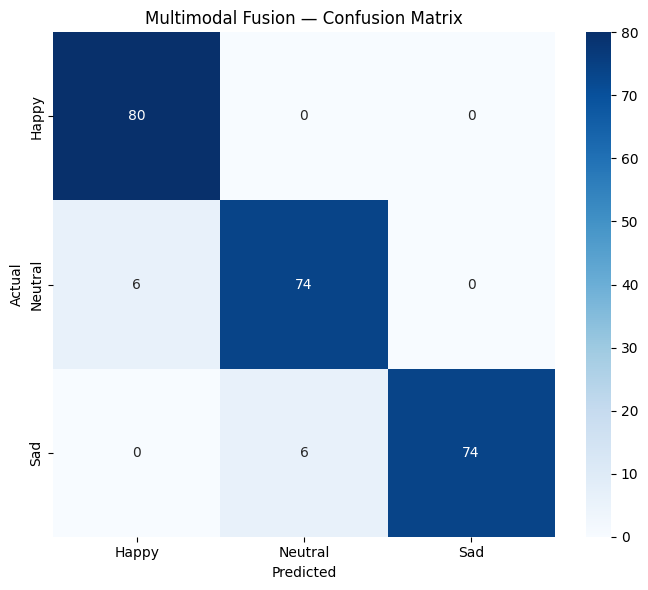

✅ Confusion matrix saved


In [ ]:
# ============================================================
# CELL 17 — Full Evaluation on Test Set (240 samples)
# ============================================================
# If Cell 12 cache was loaded → uses precomputed X_test/y_test
# features to skip re-inference and runs evaluation instantly.
# If cache not available → falls back to live inference as before.
# ============================================================

DEBUG_MODE = False

session_context.reset()
stabilizer.reset()

true_labels, pred_labels = [], []
face_rels, audio_rels    = [], []
confidences              = []
uncertain_count          = 0
conflict_count           = 0

# ── Check if precomputed test features are available ──────────
CACHE_AVAILABLE = ("X_test" in dir() and "y_test" in dir()
                   and len(X_test) == len(test_samples))

if CACHE_AVAILABLE:
    print(f"⚡ Cache available — skipping re-inference on test set.")
    print(f"   Running fusion + stabilizer on {len(test_samples)} "
          f"precomputed feature vectors...")
else:
    print(f"⚠️  No cache — running live inference on "
          f"{len(test_samples)} test samples (slower)...")

print()

# ── Evaluation loop ───────────────────────────────────────────
for idx, (f_path, a_path, label) in enumerate(test_samples):

    if CACHE_AVAILABLE:
        # ── FAST PATH: reconstruct result dicts from cached features
        feat       = X_test[idx]                          # shape (11,)

        face_res = {
            "probabilities" : feat[0:3],
            "emotion"       : COMMON_EMOTIONS[int(np.argmax(feat[0:3]))],
            "confidence"    : float(np.max(feat[0:3])),
            "reliability"   : float(feat[9]),
            "valid"         : True,
        }
        audio_res = {
            "probabilities" : feat[3:6],
            "emotion"       : COMMON_EMOTIONS[int(np.argmax(feat[3:6]))],
            "confidence"    : float(np.max(feat[3:6])),
            "reliability"   : float(feat[10]),
            "valid"         : True,
        }

    else:
        # ── SLOW PATH: full live inference (original behaviour)
        face_res  = predict_face_emotion_tta(f_path)
        audio_res = predict_audio_emotion(a_path)

    fusion_res = fuse_emotions_learned(face_res, audio_res, session_context)
    stable_res = stabilizer.update(fusion_res)
    session_context.update(stable_res["emotion"])

    true_labels.append(label)
    pred_labels.append(stable_res["emotion"])
    face_rels.append(face_res["reliability"])
    audio_rels.append(audio_res["reliability"])
    confidences.append(stable_res["confidence"])

    if fusion_res["uncertain"]: uncertain_count += 1
    if fusion_res["conflict"]:  conflict_count  += 1

    if (idx + 1) % 60 == 0:
        print(f"  Evaluated {idx+1}/{len(test_samples)}...")

# Restore debug mode
DEBUG_MODE = True

# ── Metrics ───────────────────────────────────────────────────
accuracy = accuracy_score(true_labels, pred_labels)
f1       = f1_score(true_labels, pred_labels, average="weighted")

print("\n" + "="*60)
print("FINAL SYSTEM EVALUATION")
print("="*60)
print(f"Accuracy        : {accuracy:.4f}")
print(f"F1 (weighted)   : {f1:.4f}")
print(f"Avg Confidence  : {np.mean(confidences):.3f}")
print(f"Avg Face Rel    : {np.mean(face_rels):.3f}")
print(f"Avg Audio Rel   : {np.mean(audio_rels):.3f}")
print(f"Uncertain frames: {uncertain_count}/{len(test_samples)}")
print(f"Conflict frames : {conflict_count}/{len(test_samples)}")
print(f"Inference mode  : {'⚡ cached' if CACHE_AVAILABLE else '🔍 live'}")
print("="*60)
print("\nCLASSIFICATION REPORT")
print("-"*60)
print(classification_report(true_labels, pred_labels, digits=4))

# ── Per-class accuracy breakdown ─────────────────────────────
print("PER-CLASS ACCURACY")
print("-"*60)
for i, emo in enumerate(COMMON_EMOTIONS):
    idx_mask  = [j for j, l in enumerate(true_labels) if l == emo]
    class_acc = sum(pred_labels[j] == emo for j in idx_mask) / len(idx_mask)
    print(f"  {emo:7s} : {class_acc:.4f}  "
          f"({sum(pred_labels[j]==emo for j in idx_mask)}/{len(idx_mask)})")

# ── Confusion matrix ──────────────────────────────────────────
cm = confusion_matrix(true_labels, pred_labels, labels=COMMON_EMOTIONS)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=COMMON_EMOTIONS, yticklabels=COMMON_EMOTIONS)
plt.title("Multimodal Fusion — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(METRIC_PATH, "confusion_matrix_fusion.png"), dpi=150)
plt.show()
print("✅ Confusion matrix saved")

In [ ]:
# ============================================================
# CELL 18 — SAVE COMPLETE FUSION BUNDLE TO DRIVE
# ============================================================

FUSION_BUNDLE_PATH = os.path.join(FUSION_MODEL_PATH, "fusion_bundle.pt")
FUSION_CONFIG_PATH = os.path.join(FUSION_MODEL_PATH, "fusion_config.json")

# ── Bundle dict ──────────────────────────────────────────────
fusion_bundle = {
    # trained weights
    "fusion_mlp_state":      fusion_model.state_dict(),

    # architecture config
    "fusion_input_dim":      FUSION_INPUT_DIM,
    "fusion_hidden":         64,
    "num_classes":           NUM_CLASSES,
    "common_emotions":       COMMON_EMOTIONS,

    # audio feature config (Phase 4 must reproduce identical features)
    "sample_rate":           SR,
    "fixed_length":          FIXED_LENGTH,
    "n_mels":                N_MELS,
    "n_fft":                 2048,
    "hop_length":            512,

    # calibration params
    "face_temperature":      FACE_TEMPERATURE,
    "audio_temperature":     AUDIO_TEMPERATURE,

    # temporal params
    "ema_alpha":             EMA_ALPHA,
    "transition_penalty":    TRANSITION_PENALTY,
    "buffer_size":           BUFFER_SIZE,

    # context params
    "context_window":        CONTEXT_WINDOW,
    "context_weight":        CONTEXT_WEIGHT,

    # thresholds
    "conflict_threshold":    CONFLICT_THRESHOLD,
    "uncertainty_threshold": UNCERTAINTY_THRESHOLD,
    "min_reliability":       MIN_RELIABILITY,

    # evaluation results
    "eval_accuracy":         round(accuracy, 4),
    "eval_f1":               round(f1, 4),
}

torch.save(fusion_bundle, FUSION_BUNDLE_PATH)
print(f"✅ Fusion bundle saved → {FUSION_BUNDLE_PATH}")

# ── Human-readable config JSON ────────────────────────────────
config_dict = {k: v for k, v in fusion_bundle.items()
               if k != "fusion_mlp_state"}

with open(FUSION_CONFIG_PATH, "w") as f:
    json.dump(config_dict, f, indent=2)
print(f"✅ Config JSON saved  → {FUSION_CONFIG_PATH}")

# ── Verify round-trip ─────────────────────────────────────────
loaded     = torch.load(FUSION_BUNDLE_PATH, map_location="cpu")
verify_mlp = FusionMLP(loaded["fusion_input_dim"],
                       loaded["fusion_hidden"],
                       loaded["num_classes"])
verify_mlp.load_state_dict(loaded["fusion_mlp_state"])
verify_mlp.eval()
print("✅ Round-trip load verified")
print(f"\n📦 Bundle contents:")
for k, v in loaded.items():
    if k != "fusion_mlp_state":
        print(f"   {k:<25} : {v}")

✅ Fusion bundle saved → /content/drive/MyDrive/Emotion_Story_Project1/models/fusion/fusion_bundle.pt
✅ Config JSON saved  → /content/drive/MyDrive/Emotion_Story_Project1/models/fusion/fusion_config.json
✅ Round-trip load verified

📦 Bundle contents:
   fusion_input_dim          : 11
   fusion_hidden             : 64
   num_classes               : 3
   common_emotions           : ['Happy', 'Neutral', 'Sad']
   sample_rate               : 22050
   fixed_length              : 3
   n_mels                    : 128
   n_fft                     : 2048
   hop_length                : 512
   face_temperature          : 1.2
   audio_temperature         : 1.0
   ema_alpha                 : 0.35
   transition_penalty        : 0.12
   buffer_size               : 15
   context_window            : 5
   context_weight            : 0.15
   conflict_threshold        : 0.6
   uncertainty_threshold     : 1.1
   min_reliability           : 0.15
   eval_accuracy             : 0.95
   eval_f1                 

✅ Chart saved → /content/drive/MyDrive/Emotion_Story_Project1/outputs/metrics/fusion_prob_flow.png


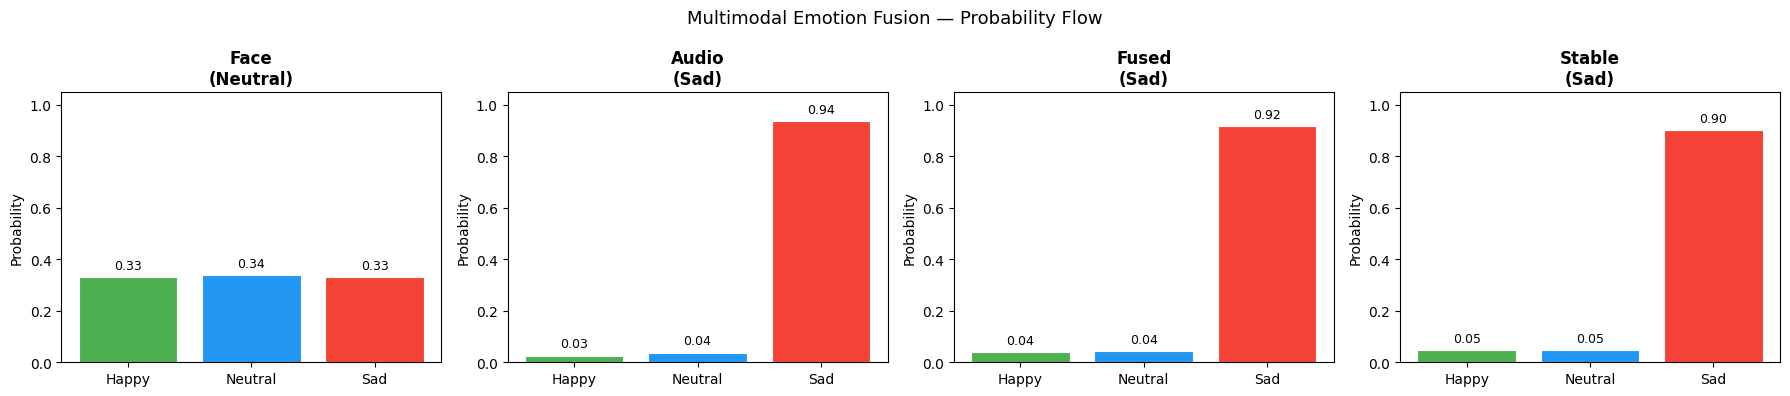

In [ ]:
# ============================================================
# CELL 19 — Confidence Bar Chart Visualisation
# ============================================================

def plot_emotion_probs(face_res, audio_res, fusion_res, stable_res, save_path=None):

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    labels = COMMON_EMOTIONS
    colors = ["#4CAF50", "#2196F3", "#F44336"]

    data = [
        (face_res["probabilities"],   f"Face\n({face_res['emotion']})"),
        (audio_res["probabilities"],  f"Audio\n({audio_res['emotion']})"),
        (fusion_res["probabilities"], f"Fused\n({fusion_res['emotion']})"),
        (stable_res["probabilities"], f"Stable\n({stable_res['emotion']})"),
    ]

    for ax, (probs, title) in zip(axes, data):
        bars = ax.bar(labels, probs, color=colors, edgecolor="white", linewidth=0.8)
        ax.set_ylim(0, 1.05)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_ylabel("Probability")
        for bar, p in zip(bars, probs):
            ax.text(bar.get_x() + bar.get_width()/2, p + 0.02,
                    f"{p:.2f}", ha="center", va="bottom", fontsize=9)

    plt.suptitle("Multimodal Emotion Fusion — Probability Flow", fontsize=13)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"✅ Chart saved → {save_path}")
    plt.show()


# Demo with smoke-test results
plot_emotion_probs(
    face_res, audio_res, fusion_res, stable_res,
    save_path=os.path.join(METRIC_PATH, "fusion_prob_flow.png")
)

🚀 Multimodal Fusion Demo — Selection
FACE INPUT MODE :
  1 → Upload Image
  2 → Webcam Capture
  0 → Skip Face Input
-------------------------------------------
Enter choice for Face (1, 2, or 0): 1

AUDIO INPUT MODE :
  3 → Upload Audio
  4 → Record Audio
  0 → Skip Audio Input
-------------------------------------------
Enter choice for Audio (3, 4, or 0): 3
📤 Upload a face image (jpg / png):



Saving sad face6.png to sad face6.png
✅ Image uploaded: sad face6.png

📤 Upload a .wav audio file:



Saving sad_audio.wav to sad_audio (1).wav
✅ Audio uploaded: sad_audio (1).wav



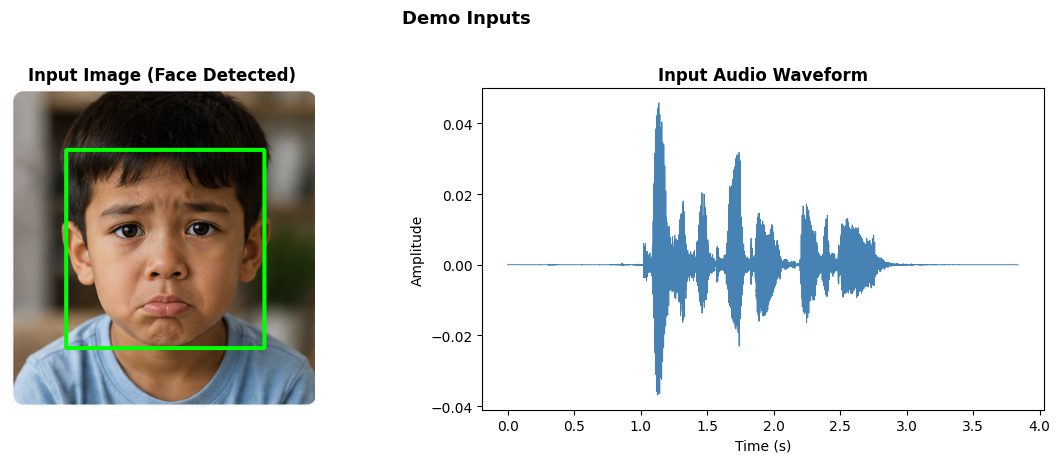

🔊 Playing input audio...


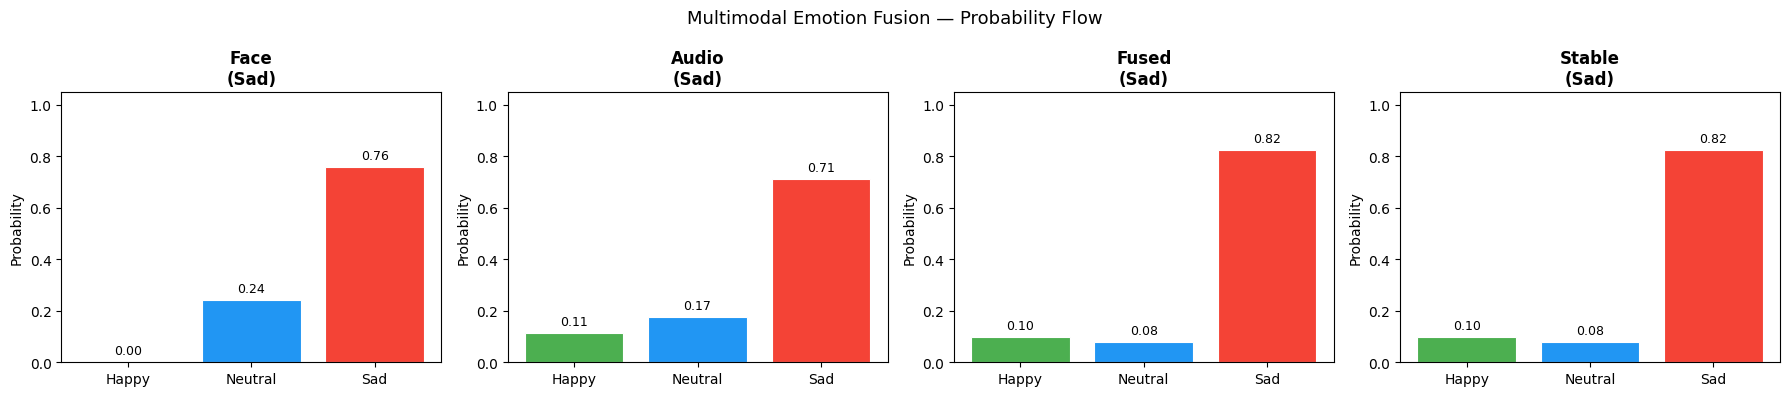


🏆 FINAL DECISION : SAD
   Confidence     : 0.8234 (82.3%)
   Uncertain      : False  |  Conflict: False
   Session Context: Unknown
-----------------------------------------------------------------
   Unimodal Outputs:
     Face         : Sad     (conf=0.760, valid=True)
     Audio        : Sad     (conf=0.712, valid=True)
     Fused (Raw)  : Sad     (conf=0.823)


In [ ]:
# ==========================================
# CELL 20 — Multimodal Quick Demo
# Upload or capture face/audio and see
# predictions instantly. Perfect for live demo!
# ==========================================

from google.colab import files
from IPython.display import display, HTML, Audio
from google.colab.output import eval_js
from base64 import b64decode
import io
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from PIL import Image

# ============================================================
# Option A — Face Input Functions
# ============================================================

def demo_upload_face():
    """Upload one face image from device."""
    print("📤 Upload a face image (jpg / png):\n")
    uploaded = files.upload()
    if not uploaded:
        print("⚠️ No file uploaded.")
        return None
    filename = list(uploaded.keys())[0]
    save_path = f"/content/{filename}"
    with open(save_path, "wb") as f:
        f.write(uploaded[filename])
    print(f"✅ Image uploaded: {filename}\n")
    return save_path

def demo_webcam():
    """Capture a photo from webcam."""
    JS_CODE = """
    async function captureWebcam() {
        const div = document.createElement('div');
        const video = document.createElement('video');
        video.style.display = 'block';
        video.style.borderRadius = '10px';
        video.style.margin = '10px auto';

        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();

        // Wait a moment for the camera to adjust
        await new Promise(resolve => setTimeout(resolve, 1500));

        const canvas = document.createElement('canvas');
        canvas.width  = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getVideoTracks()[0].stop();
        div.remove();

        return canvas.toDataURL('image/jpeg', 0.9);
    }
    """
    print("📷 Opening webcam... (allow camera access)")
    data_url = eval_js(JS_CODE + '\ncaptureWebcam()')
    header, encoded = data_url.split(',', 1)
    img_bytes = b64decode(encoded)

    webcam_path = "/content/webcam_capture.jpg"
    with open(webcam_path, "wb") as f:
        f.write(img_bytes)
    print("✅ Photo captured!\n")
    return webcam_path

# ============================================================
# Option B — Audio Input Functions
# ============================================================

def demo_upload_audio():
    """Upload one audio file from device."""
    print("📤 Upload a .wav audio file:\n")
    uploaded = files.upload()
    if not uploaded:
        print("⚠️ No file uploaded.")
        return None
    filename = list(uploaded.keys())[0]
    save_path = f"/content/{filename}"
    with open(save_path, "wb") as f:
        f.write(uploaded[filename])
    print(f"✅ Audio uploaded: {filename}\n")
    return save_path

def demo_record_mic():
    """Record audio from microphone."""
    RECORD_JS = """
    async function recordAudio() {
        const stream = await navigator.mediaDevices.getUserMedia({audio: true});
        const mediaRecorder = new MediaRecorder(stream, {mimeType: 'audio/webm'});
        const chunks = [];

        mediaRecorder.ondataavailable = (e) => chunks.push(e.data);

        // Create a simple UI for recording
        const div = document.createElement('div');
        div.style.cssText = 'text-align:center; padding:20px; margin:10px auto; ' +
                            'background:#f0f4f8; border-radius:12px; max-width:400px; ' +
                            'font-family:sans-serif;';

        const status = document.createElement('p');
        status.style.cssText = 'font-size:18px; font-weight:bold; color:#d32f2f;';
        status.textContent = '\\u26ab Recording... Speak now!';

        const stopBtn = document.createElement('button');
        stopBtn.textContent = '\\u23f9  Stop Recording';
        stopBtn.style.cssText = 'padding:12px 28px; font-size:16px; cursor:pointer; ' +
                                'background:#d32f2f; color:white; border:none; ' +
                                'border-radius:8px; margin-top:10px;';

        div.appendChild(status);
        div.appendChild(stopBtn);
        document.body.appendChild(div);

        mediaRecorder.start();

        const result = await new Promise(resolve => {
            stopBtn.onclick = () => {
                mediaRecorder.stop();
                status.textContent = '\\u2705 Recording stopped.';
                status.style.color = '#388e3c';
                stopBtn.disabled = true;
                stopBtn.style.background = '#9e9e9e';
            };
            mediaRecorder.onstop = async () => {
                stream.getTracks().forEach(t => t.stop());
                const blob = new Blob(chunks, {type: 'audio/webm'});
                const reader = new FileReader();
                reader.onloadend = () => resolve(reader.result);
                reader.readAsDataURL(blob);
            };
        });

        div.remove();
        return result;
    }
    """
    print("🎙️  Recording from microphone...")
    print("   Speak into your mic, then click the Stop button.\n")
    data_url = eval_js(RECORD_JS + '\nrecordAudio()')
    header, encoded = data_url.split(',', 1)
    audio_bytes = b64decode(encoded)

    webm_path = "/content/mic_recording.webm"
    wav_path  = "/content/mic_recording.wav"

    with open(webm_path, "wb") as f:
        f.write(audio_bytes)

    import subprocess
    subprocess.run(
        ["ffmpeg", "-y", "-i", webm_path, "-ar", str(SR),
         "-ac", "1", wav_path],
        capture_output=True
    )

    if not os.path.exists(wav_path):
        print("❌ Failed to convert recording to WAV.")
        return None

    print("✅ Recording saved & converted to WAV!\n")
    return wav_path

# ============================================================
# Helper — Visualize Inputs
# ============================================================

def show_multimodal_inputs(face_path, audio_path):
    has_face = face_path is not None
    has_audio = audio_path is not None
    if not has_face and not has_audio:
        return

    num_plots = int(has_face) + int(has_audio)
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 4.5))
    if num_plots == 1:
        axes = [axes]

    ax_idx = 0
    if has_face:
        img_bgr = cv2.imread(face_path)
        if img_bgr is not None:
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
            faces = face_detector.detectMultiScale(
                gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60)
            )
            display_img = img_rgb.copy()
            if len(faces) > 0:
                x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
                cv2.rectangle(display_img, (x, y), (x+w, y+h), (0, 255, 0), 3)
                axes[ax_idx].set_title("Input Image (Face Detected)", fontsize=12, fontweight='bold')
            else:
                axes[ax_idx].set_title("Input Image (No Face Detected)", fontsize=12, fontweight='bold')
            axes[ax_idx].imshow(display_img)
            axes[ax_idx].axis("off")
        else:
            axes[ax_idx].text(0.5, 0.5, "Error loading face image", ha="center", va="center")
            axes[ax_idx].axis("off")
        ax_idx += 1

    if has_audio:
        try:
            y, sr = librosa.load(audio_path, sr=SR)
            axes[ax_idx].plot(np.linspace(0, len(y)/sr, len(y)), y, color="steelblue", linewidth=0.7)
            axes[ax_idx].set_title("Input Audio Waveform", fontsize=12, fontweight='bold')
            axes[ax_idx].set_xlabel("Time (s)")
            axes[ax_idx].set_ylabel("Amplitude")
        except Exception as e:
            axes[ax_idx].text(0.5, 0.5, f"Error loading audio: {e}", ha="center", va="center")
            axes[ax_idx].axis("off")
        ax_idx += 1

    plt.suptitle("Demo Inputs", fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    if has_audio:
        try:
            y, sr = librosa.load(audio_path, sr=SR)
            print("🔊 Playing input audio...")
            display(Audio(y, rate=sr))
        except Exception as e:
            print(f"⚠️ Could not load audio player: {e}")

# ============================================================
# Main Execution Loop
# ============================================================

print("===========================================")
print("🚀 Multimodal Fusion Demo — Selection")
print("===========================================")
print("FACE INPUT MODE :")
print("  1 → Upload Image")
print("  2 → Webcam Capture")
print("  0 → Skip Face Input")
print("-------------------------------------------")
face_choice = input("Enter choice for Face (1, 2, or 0): ").strip()

print("\nAUDIO INPUT MODE :")
print("  3 → Upload Audio")
print("  4 → Record Audio")
print("  0 → Skip Audio Input")
print("-------------------------------------------")
audio_choice = input("Enter choice for Audio (3, 4, or 0): ").strip()

if face_choice == "0" and audio_choice == "0":
    print("\n" + "="*65)
    print("Default Message: Demonstration skipped (Both inputs skipped)")
    print("="*65)
else:
    face_path = None
    if face_choice == "1":
        face_path = demo_upload_face()
    elif face_choice == "2":
        face_path = demo_webcam()
    elif face_choice == "0":
        print("⏭️ Skipping Face Input.")
    else:
        print("⚠️ Invalid Face choice. Skipping Face Input.")

    audio_path = None
    if audio_choice == "3":
        audio_path = demo_upload_audio()
    elif audio_choice == "4":
        audio_path = demo_record_mic()
    elif audio_choice == "0":
        print("⏭️ Skipping Audio Input.")
    else:
        print("⚠️ Invalid Audio choice. Skipping Audio Input.")

    # ── Inference ──────────────────────────────────────────
    if face_path is not None:
        face_res = predict_face_emotion_tta(face_path)
    else:
        face_res = {
            "emotion": "Neutral",
            "probabilities": np.array([0.33, 0.34, 0.33]),
            "confidence": 0.0,
            "quality": 0.0,
            "reliability": 0.0,
            "entropy": 1.585,
            "valid": False
        }

    if audio_path is not None:
        audio_res = predict_audio_emotion(audio_path)
    else:
        audio_res = {
            "emotion": "Neutral",
            "probabilities": np.array([0.33, 0.34, 0.33]),
            "confidence": 0.0,
            "quality": 0.0,
            "reliability": 0.0,
            "entropy": 1.585,
            "valid": False
        }

    # Reset stabilizers/context for clean demo state
    session_context.reset()
    stabilizer.reset()

    # Disable debug output to prevent pollution of final demo layout
    global DEBUG_MODE
    orig_debug = DEBUG_MODE
    DEBUG_MODE = False

    try:
        fusion_res = fuse_emotions_learned(face_res, audio_res, session_context)
        stable_res = stabilizer.update(fusion_res)
        session_context.update(stable_res["emotion"])
    finally:
        DEBUG_MODE = orig_debug

    # ── Visualisation ─────────────────────────────────────
    show_multimodal_inputs(face_path, audio_path)
    plot_emotion_probs(face_res, audio_res, fusion_res, stable_res)

    # Text summary box
    print(f"\n{'='*65}")
    print(f"🏆 FINAL DECISION : {stable_res['emotion'].upper()}")
    print(f"   Confidence     : {stable_res['confidence']:.4f} ({stable_res['confidence']:.1%})")
    print(f"   Uncertain      : {fusion_res['uncertain']}  |  Conflict: {fusion_res['conflict']}")
    print(f"   Session Context: {fusion_res['context_emotion']}")
    print(f"{'-'*65}")
    print(f"   Unimodal Outputs:")
    print(f"     Face         : {face_res['emotion']:7s} (conf={face_res['confidence']:.3f}, valid={face_res['valid']})")
    print(f"     Audio        : {audio_res['emotion']:7s} (conf={audio_res['confidence']:.3f}, valid={audio_res['valid']})")
    print(f"     Fused (Raw)  : {fusion_res['emotion']:7s} (conf={fusion_res['confidence']:.3f})")
    print(f"{'='*65}")

In [ ]:
# ============================================================
# CELL 21 — Phase 3 Summary
# ============================================================

print("\n" + "█"*60)
print("  PHASE 3 COMPLETE — FUSION BUNDLE READY FOR PHASE 4")
print("█"*60)
print(f"""
  Saved artefacts:
  ├── {FUSION_BUNDLE_PATH}
  │      → FusionMLP weights + all hyperparams
  ├── {FUSION_CONFIG_PATH}
  │      → Human-readable JSON config
  └── {METRIC_PATH}/
         → confusion_matrix_fusion.png
         → fusion_prob_flow.png

  System eval on {len(test_samples)} samples:
    Accuracy : {accuracy:.4f}
    F1       : {f1:.4f}

  What Phase 4 will load:
    FusionMLP  → final emotion prediction
    ContextAwareness → session history bias
    TemporalStabilizer → EMA smoothing
    Uncertainty flag → fallback in UI
""")
print("█"*60)


████████████████████████████████████████████████████████████
  PHASE 3 COMPLETE — FUSION BUNDLE READY FOR PHASE 4
████████████████████████████████████████████████████████████

  Saved artefacts:
  ├── /content/drive/MyDrive/Emotion_Story_Project1/models/fusion/fusion_bundle.pt
  │      → FusionMLP weights + all hyperparams
  ├── /content/drive/MyDrive/Emotion_Story_Project1/models/fusion/fusion_config.json
  │      → Human-readable JSON config
  └── /content/drive/MyDrive/Emotion_Story_Project1/outputs/metrics/
         → confusion_matrix_fusion.png
         → fusion_prob_flow.png

  System eval on 240 samples:
    Accuracy : 0.9500
    F1       : 0.9500

  What Phase 4 will load:
    FusionMLP  → final emotion prediction
    ContextAwareness → session history bias
    TemporalStabilizer → EMA smoothing
    Uncertainty flag → fallback in UI

████████████████████████████████████████████████████████████
